输入节点先给一个编排器

看起来像并行执行，但是这里并不知道工作节点有多少步

#### 13.2.4.1. 核心思想

编排器先分析任务，动态生成若干子任务，再创建对应数量的 Worker：

```text
                         ┌→ Worker 1 ─┐
输入 → Orchestrator ─────┼→ Worker 2 ─┼→ Synthesizer → 输出
                         ├→ Worker 3 ─┤
                         └→ Worker N ─┘
```

它通常包含三个组件：

| 组件 | 职责 |
|:---|:---|
| **`Orchestrator`**（编排器） | 分析任务、制定计划、生成子任务列表 |
| **`Workers`**（工作节点） | 分别处理各子任务，通常并行执行 |
| **`Synthesizer`**（聚合节点） | 汇总所有 Worker 结果，生成最终答案 |

适合任务数量无法预先确定的场景，例如：

* 根据主题动态生成报告章节
* 修改未知数量的代码文件
* 为多个数据源分别执行分析
* 将长文档动态拆分为若干部分处理

#### 13.2.4.2. 和`Parallelization`的区别

| 模式 | 任务数量 |
|:---|:---|
| **`Parallelization`** | 编译图时已确定（静态） |
| **`Orchestrator-worker`** | 运行时动态计算 |

#### 13.2.4.3. 本质

**`Orchestrator-worker`** 本质上就是 **`Map-Reduce`**，我们在前面的课程中已经实现过了

```text
Orchestrator：生成 Map 任务
Send：动态分发
Worker：执行 Map
Reducer：合并中间结果
Synthesizer：执行 Reduce
```

2026-09-20 09:44:39.803 | INFO     | __main__:orchestrator:69 - sections=[Section(name='引言：为什么缩放定律至关重要', description='介绍大语言模型发展的核心驱动力——规模（参数量、数据量、算力），阐明缩放定律作为可预测性工具的意义。概述报告结构，并点出缩放定律在模型设计、资源分配和训练决策中的实际价值。'), Section(name='缩放定律的理论基础与数学形式', description='阐述缩放定律的基本数学表达，包括幂律关系、损失函数与模型规模/数据量/计算量的依赖关系。重点介绍Kaplan等人（2020）提出的原始公式及其形式，解释其中的关键参数和指数含义。'), Section(name='Chinchilla 范式：数据与参数的最优配比', description='深入分析DeepMind的Chinchilla论文对Kaplan定律的修正，说明“计算最优”训练策略——数据量应与参数量近似等比增长。对比GPT-3等模型的“欠训练”问题，讨论该发现对后续模型训练实践的深远影响。'), Section(name='幂律背后的机制：为何缩放如此有效', description='从理论角度探讨缩放定律的经验规律背后可能的解释，包括神经标度理论、损失景观、数据分布维度等视角。分析幂律的适用范围与偏离现象（如涌现能力、双重下降），讨论缩放何时失效。'), Section(name='缩放定律的实践应用与工程指导', description='说明缩放定律如何指导实际训练决策：学习率调度、批量大小选择、模型架构参数搭配、训练时长规划。介绍基于小规模实验预测大规模性能的方法，以及其在算力预算分配中的作用。'), Section(name='超越经典缩放：新维度与新挑战', description='探讨缩放定律的扩展方向，包括数据质量与数据混合比例的影响、多模态缩放、推理时计算缩放（test-time compute）、MoE架构下的缩放行为、以及语言模型之外的领域（如视觉、科学计算）的缩放规律。'), Section(name='争议、局限与未解问题', description='讨论学界对缩放定律的批评与争议：经验拟合的因果解释缺失、涌现能力是否真实存在、

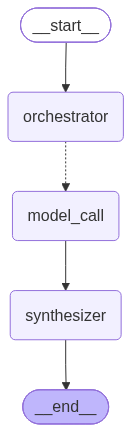

# 引言：为什么缩放定律至关重要

## 规模：大语言模型发展的核心驱动力

过去几年，大语言模型（Large Language Model, LLM）的能力演进呈现出一种近乎直觉却极其深刻的规律：**规模越大，性能越好**。这里的“规模”并非单一维度，而是由三个相互关联的要素共同构成：

- **参数量（Model Size）**：模型内部可学习权重的数量，决定了模型的表示容量与记忆能力。从早期数亿参数的模型到如今数千亿乃至万亿参数级别的系统，参数量的增长直接拓展了模型能够拟合的函数空间。
- **数据量（Data Size）**：训练所用的 token 总数。更多的数据意味着模型能够接触到更广泛的语言现象、知识片段和推理模式，从而降低过拟合风险并提升泛化能力。
- **算力（Compute）**：训练过程中消耗的总浮点运算次数（FLOPs），是参数量与数据量的乘积性约束。算力决定了在给定时间内能够完成多少参数更新，是连接模型与数据的物理桥梁。

这三者并非独立发挥作用，而是以高度耦合的方式共同决定模型的最终性能。然而，仅凭“越大越好”的直觉并不足以指导工程实践——盲目扩大规模可能导致资源浪费、训练不稳定甚至性能下降。真正让规模增长从“试错”走向“可预测”的，是**缩放定律（Scaling Laws）**。

## 缩放定律：规模增长的可预测性工具

缩放定律的核心洞见在于：**模型性能（通常以测试损失衡量）与参数量、数据量、算力之间，存在可被数学描述的幂律关系**。这意味着，在投入大规模训练之前，研究者可以通过小规模实验拟合出损失曲线，并据此外推更大规模下的预期性能。

这一发现的意义远超学术兴趣。它将大模型训练从“炼金术”转变为“工程科学”：

- **可预测性**：给定计算预算，可以预先估计不同参数量与数据量组合下的最终损失，从而避免昂贵的盲试。
- **可指导性**：缩放定律揭示了参数量与数据量之间的最优分配比例（如 Chinchilla 定律所强调的“训练 token 数应与参数量同比例增长”），为资源分配提供量化依据。
- **可比较性**：不同架构、不同训练策略的模型可以在同一缩放框架下进行公平比较，推动架构创新与训练方法迭代。

简言之，缩放定律是连接“规模投入”与“性能产出”的桥梁，是让大模型研发从经验驱动走向理论指导的关键工具。

## 本报告的结构与核心议题

本报告将围绕缩放定律展开系统论述，结构安排如下：

1. **缩放定律的基本形式与数学基础**：介绍 Kaplan 等人与 Chinchilla 等工作的核心公式，阐明幂律关系、计算最优边界及其推导逻辑。
2. **缩放定律在模型设计中的应用**：讨论如何利用缩放定律确定参数量、数据量与模型架构（如深度、宽度、注意力头数）的合理配置。
3. **缩放定律在资源分配与训练决策中的价值**：分析计算预算的最优分配策略、训练早期性能预测、以及何时停止训练等实际决策问题。
4. **缩放定律的局限与前沿挑战**：探讨数据质量、架构变更、推理能力涌现等因素对缩放规律的偏离，以及未来可能的研究方向。
5. **结论与展望**：总结缩放定律对大模型发展的深远影响，并展望其在多模态、推理增强等新场景下的演化路径。

## 缩放定律的实际价值：从设计到决策

缩放定律并非停留在论文中的理论公式，而是已经深度嵌入工业级大模型研发的各个环节：

- **模型设计**：在架构搜索阶段，缩放定律帮助团队快速筛选出在目标算力下最有潜力的参数规模与数据配比，避免在无效配置上浪费算力。
- **资源分配**：在给定 GPU 集群规模与训练时间约束下，缩放定律指导如何平衡模型大小与训练步数，实现计算最优或推理最优的训练方案。
- **训练决策**：在训练过程中，缩放定律可用于早期损失外推，判断当前训练是否偏离预期，从而及时调整超参数或终止低效训练。

可以说，**没有缩放定律，大模型训练将退化为高风险的资源赌博；有了缩放定律，规模增长才成为可规划、可优化、可复现的工程实践**。这正是本报告试图系统阐述的核心命题。

---

# 缩放定律的理论基础与数学形式

## 幂律关系的基本形式

缩放定律的核心在于描述模型性能指标（通常为交叉熵损失）与模型规模、训练数据量、计算量之间的幂律依赖关系。幂律关系的一般形式可表示为：

$$
L(x) = \alpha \cdot x^{-\beta}
$$

其中 $L$ 为损失值，$x$ 为某一缩放变量（如参数量 $N$、数据量 $D$ 或计算量 $C$），$\alpha$ 为比例系数，$\beta$ 为缩放指数。该形式在对数-对数坐标下呈现为直线，斜率为 $-\beta$。

## Kaplan 等人（2020）的原始公式

Kaplan 等人在论文《Scaling Laws for Neural Language Models》中，基于 Transformer 架构的语言模型实验，提出了损失与模型规模、数据量、计算量之间的具体幂律关系。其核心发现包括以下三方面：

### 1. 损失与模型参数量 $N$ 的关系

当数据量足够大、训练充分时，测试损失随模型参数量 $N$ 呈幂律下降：

$$
L(N) = \left(\frac{N_c}{N}\right)^{\alpha_N}
$$

其中 $N_c$ 为特征参数量尺度，$\alpha_N$ 为模型规模缩放指数。Kaplan 等人实验中估计 $\alpha_N \approx 0.076$，表明损失随参数量增加而缓慢但稳定地下降。

### 2. 损失与数据量 $D$ 的关系

在固定模型规模下，损失随训练数据量 $D$ 的增加同样呈幂律下降：

$$
L(D) = \left(\frac{D_c}{D}\right)^{\alpha_D}
$$

其中 $D_c$ 为特征数据量尺度，$\alpha_D$ 为数据缩放指数，实验中估计 $\alpha_D \approx 0.095$。

### 3. 损失与计算量 $C$ 的关系

计算量 $C$ 通常近似为 $C \approx 6ND$（前向与反向传播的总浮点运算量）。当模型规模与数据量按最优比例分配时，损失与计算量满足：

$$
L(C) = \left(\frac{C_c}{C}\right)^{\alpha_C}
$$

其中 $\alpha_C \approx 0.050$，$C_c$ 为特征计算量尺度。

## 联合缩放公式

Kaplan 等人进一步提出了同时考虑模型规模与数据量的联合缩放公式：

$$
L(N, D) = \left[\left(\frac{N_c}{N}\right)^{\frac{\alpha_N}{\alpha_D}} + \frac{D_c}{D}\right]^{\alpha_D}
$$

该公式表明，当 $N$ 和 $D$ 同时增加时，损失下降受两者中较“瓶颈”的一方主导。当模型规模远大于数据量时，损失主要由数据量不足限制；反之则由模型容量限制。

## 关键参数与指数含义

- **比例系数（$N_c, D_c, C_c$）**：反映特定架构与训练设置下的特征尺度，决定了幂律曲线的位置，但不影响其斜率。
- **缩放指数（$\alpha_N, \alpha_D, \alpha_C$）**：决定损失随规模增长的下降速率。指数越小，说明该维度上增加投入带来的收益越缓慢。
- **计算量系数 6**：源于 Transformer 每参数每 token 的前向与反向传播约需 6 次浮点运算（前向 2 次、反向 4 次）的估算。
- **不可约损失 $L_\infty$**：当规模趋于无穷时，损失收敛的下界，反映了数据本身的熵与任务固有难度。

## 数学形式的意义

上述幂律形式揭示了一个重要结论：模型性能的提升遵循可预测的、平滑的规律，而非随机或突变的。这使得研究者能够在小规模实验的基础上，外推大规模模型的预期损失，从而指导计算资源的分配与模型设计决策。Kaplan 等人的工作为后续 Chinchilla 缩放定律（Hoffmann 等人，2022）奠定了基础，后者进一步修正了模型规模与数据量之间的最优配比关系。

---

# Chinchilla 范式：数据与参数的最优配比

## 对 Kaplan 定律的修正

2020 年，Kaplan 等人基于一系列不同规模的语言模型训练实验，提出了著名的缩放定律（Scaling Laws），指出模型性能与参数量、数据量和计算量之间存在幂律关系。Kaplan 定律的核心结论倾向于：在固定计算预算下，应优先扩大模型参数量，而数据量的增长可以相对滞后。这一结论深刻影响了 GPT-3 等模型的训练策略——GPT-3 拥有 1750 亿参数，但训练数据仅约 3000 亿 token，参数量与数据量的比例严重失衡。

2022 年，DeepMind 发表 Chinchilla 论文，对 Kaplan 定律进行了系统性修正。研究团队指出，Kaplan 等人的实验存在两个关键问题：其一，学习率调度未随训练步数充分调整，导致长训练运行的结果被低估；其二，部分实验的数据量未达到饱和，使得数据效率被高估。在修正这些实验设定后，Chinchilla 得出了截然不同的结论。

## 计算最优训练策略

Chinchilla 的核心发现是：在给定的计算预算下，模型参数量与训练数据量应近似等比增长。具体而言，最优配置下，每训练一个参数大约需要 20 个 token 的数据。这一比例远高于此前实践的惯例——GPT-3 的 token/参数比约为 1.7，而 Chinchilla 的最优比例约为 20。

以计算最优为目标，Chinchilla 团队训练了一个 700 亿参数的模型，使用 1.4 万亿 token 的数据。该模型在多个基准测试上全面超越了参数量为其 2.5 倍的 GPT-3（1750 亿参数），而训练计算量基本相同。这一结果直接证明：此前的超大模型普遍处于“欠训练”状态，参数规模远超数据量所支撑的最优水平。

## GPT-3 等模型的“欠训练”问题

GPT-3 是“欠训练”问题的典型代表。其 1750 亿参数仅搭配约 3000 亿 token 的训练数据，token/参数比远低于 Chinchilla 最优值。这意味着，在相同的计算预算下，如果缩小模型规模并增加训练数据，可以获得更好的性能表现。类似地，GPT-2、Gopher 等模型也面临相同的效率问题。

“欠训练”不仅造成计算资源的浪费，还导致模型在推理时承载了不必要的参数开销。一个经过充分训练的小模型，可以在推理成本更低的情况下达到甚至超越欠训练大模型的效果。

## 对后续模型训练实践的深远影响

Chinchilla 的发现迅速改变了大型语言模型的训练范式。此后，主流模型普遍大幅提升了训练数据量：

- **LLaMA 系列**：Meta 的 LLaMA 模型明确遵循 Chinchilla 最优策略，7B 参数模型使用 1 万亿 token 训练，token/参数比远超 GPT-3。
- **GPT-4**：虽未公开细节，但业界普遍推测其训练数据量较 GPT-3 有数量级提升。
- **开源模型生态**：Chinchilla 的最优比例成为开源模型训练的标准参考，推动了对高质量数据集的更大规模投入。

同时，Chinchilla 也引发了对“推理最优”与“训练最优”之间权衡的讨论。在实际部署中，如果推理成本占主导，则可能倾向于训练一个更小但训练更充分的模型，而非严格遵循计算最优比例。这一思路后来被进一步发展为“过度训练”（over-training）策略——在固定模型规模下使用远超 Chinchilla 最优的数据量，以牺牲训练效率换取更低的推理成本。LLaMA 系列和后续的许多开源模型均采用了这一策略。

总体而言，Chinchilla 范式标志着大模型训练从“参数竞赛”转向“数据与参数的均衡配比”，成为现代语言模型训练实践的重要理论基石。

---

# 幂律背后的机制：为何缩放如此有效

## 1. 引言

缩放定律（Scaling Laws）在深度学习领域，尤其是大语言模型中，展现出惊人的经验规律性：模型性能（通常以交叉熵损失衡量）与模型参数量、数据规模、计算量之间呈现出稳健的幂律关系。这种规律不仅具有预测能力，还深刻影响了模型设计与训练策略。然而，幂律为何成立？其背后的理论机制是什么？在哪些情况下会失效？本章将从神经标度理论、损失景观、数据分布维度等视角探讨这些问题，并分析幂律的适用范围与偏离现象。

## 2. 神经标度理论：从随机特征到核回归

神经标度理论试图从神经网络的学习动力学出发，解释幂律的来源。早期工作将宽神经网络的训练行为近似为核方法，特别是神经正切核（NTK）或随机特征模型。在这些框架下，学习曲线（损失随样本数或模型宽度的变化）可以解析地推导出幂律指数。

- **随机特征模型**：当模型宽度趋于无穷时，网络等价于一个线性模型在随机特征空间中的回归。此时，损失随样本数 \( n \) 的下降速率由目标函数在特征空间中的谱衰减决定。若特征值按 \( \lambda_i \sim i^{-\alpha} \) 衰减，则损失按 \( n^{-\alpha} \) 下降。
- **NTK 与懒惰训练**：在 NTK  regime 下，网络在训练过程中变化极小，学习等价于核回归。此时，缩放指数由核的平滑性和数据分布的维度决定。
- **特征学习与富训练**：当网络脱离懒惰训练，特征本身随训练更新，缩放行为可能改变。近期研究指出，特征学习可以导致更快的缩放指数，甚至出现相变。

这些理论表明，幂律并非偶然，而是源于数据分布与模型容量之间的谱匹配关系。

## 3. 损失景观与有效维度

损失景观的几何性质为幂律提供了另一视角。在高维参数空间中，损失函数的曲率、平坦性和连通性影响优化与泛化。

- **有效维度**：模型的有效参数量或数据的内在维度决定了学习问题的复杂度。若数据分布集中在一个低维流形上，则泛化误差随样本数的下降速率由该流形的维度决定。幂律指数往往与内在维度相关。
- **损失景观的平坦性**：平坦极小值通常对应更好的泛化。随着模型增大，损失景观变得更平坦，梯度噪声相对减小，从而允许更高效的优化。这种平坦性与幂律缩放中的指数衰减有关。
- **相变与涌现**：损失景观中可能存在相变点，导致某些能力突然涌现。这些偏离幂律的现象提示缩放并非无条件成立。

## 4. 数据分布维度与幂律指数

数据分布的特性直接决定缩放指数。对于自然语言、图像等真实数据，其分布往往具有长尾、重尾或分形结构。

- **内在维度**：数据的内在维度 \( d \) 决定了学习所需样本量随误差的缩放关系。若数据均匀分布于 \( d \) 维超立方体，则损失按 \( n^{-2/d} \) 下降。真实数据的内在维度通常远低于像素或词表维度，但高于 1，导致幂律指数介于 0 与 1 之间。
- **重尾分布**：语言中词频服从 Zipf 定律，图像中边缘统计具有尺度不变性。这些重尾特性导致损失曲线呈现幂律，而非指数衰减。
- **任务多样性**：多任务学习或混合数据分布下，缩放指数可能由最难的任务或最稀有的模式主导，导致偏离单一幂律。

## 5. 幂律的适用范围与偏离现象

尽管幂律在多数情况下成立，但存在若干偏离现象，提示其适用边界。

### 5.1 涌现能力

涌现能力指模型在规模达到某一阈值后，突然获得某项能力（如算术、推理）。这种现象表现为损失曲线上的拐点或能力指标的非连续跃升。可能原因包括：
- 任务需要组合多个子技能，子技能各自按幂律改进，但组合后表现为阈值行为。
- 评估指标的非线性（如精确匹配）导致连续改进在指标上表现为突变。
- 模型内部表征发生相变，从量变到质变。

涌现能力挑战了“缩放可预测”的假设，但近期研究认为，若采用连续指标（如对数似然），涌现可能消失，表明其部分源于度量选择。

### 5.2 双重下降

双重下降指测试误差随模型复杂度增加先降后升再降的现象。在深度学习中，过参数化区域误差再次下降，与经典偏差-方差权衡相悖。双重下降偏离了单一幂律，表明：
- 在插值阈值附近，缩放行为可能暂时恶化。
- 过参数化后，隐式正则化（如梯度下降的偏好）导致更优解，恢复幂律。
- 双重下降的峰值位置与数据噪声、模型架构有关。

### 5.3 缩放何时失效

幂律失效可能发生在以下情形：
- **数据耗尽**：当高质量数据有限，增加模型参数量不再带来相应性能提升，缩放指数急剧下降。
- **容量饱和**：模型容量远超任务复杂度，损失趋于不可约误差（如贝叶斯误差），幂律终止。
- **分布偏移**：训练分布与测试分布不一致时，缩放规律可能不再适用。
- **优化困难**：极大模型训练不稳定，导致损失曲线偏离幂律。
- **任务不可约误差**：某些任务存在内在随机性，损失下界不为零，幂律最终平坦。

## 6. 讨论与展望

幂律的普遍性源于数据分布、模型容量与优化动力学之间的深层联系。神经标度理论、损失景观几何与数据内在维度共同提供了理论解释。然而，幂律并非万能：涌现能力、双重下降和数据耗尽等现象揭示了其局限。未来研究需进一步统一理论框架，理解特征学习对缩放指数的影响，并开发更鲁棒的评估指标以区分真实能力提升与度量假象。缩放定律仍是指导大模型训练的有力工具，但需谨慎对待其适用边界。

---

# 缩放定律的实践应用与工程指导

## 学习率调度

缩放定律为学习率调度提供了定量化的设计依据。实践中最常用的策略是余弦退火配合线性预热，而缩放定律进一步揭示了最优学习率与模型规模、批量大小之间的幂律关系。具体而言，当模型参数量增大时，最优初始学习率通常需要相应下调，其缩放指数可通过小规模实验拟合获得；当批量大小增大时，最优学习率大致按平方根或线性比例提升，这一关系直接决定了「学习率—批量大小」的联合调节方案。

在训练时长规划方面，缩放定律表明最优学习率与训练步数之间存在幂律衰减关系，即训练越久，学习率应越低。这为余弦退火终点的设定提供了理论支撑：若计划训练步数发生变化，不应简单沿用固定的调度曲线，而需按缩放指数重新校准峰值学习率与衰减速率，否则会导致欠训练或过训练。

## 批量大小选择

批量大小是影响训练效率与最终性能的关键超参数。缩放定律指出存在一个临界批量大小，当批量大小低于该临界值时，增大批量能有效降低梯度噪声、加速收敛；超过临界值后，继续增大批量带来的收益迅速递减，甚至损害泛化能力。

临界批量大小与模型规模、数据分布及训练目标相关，可通过小规模实验中的梯度噪声尺度进行估计。工程实践中，常采用「线性缩放规则」作为起点，再依据临界批量大小的预测结果进行修正。此外，缩放定律支持在固定计算预算下对批量大小与训练步数进行联合优化，从而在吞吐效率与样本效率之间取得平衡。

## 模型架构参数搭配

缩放定律揭示了模型性能与参数量、数据量、计算量之间的幂律关系，为架构参数搭配提供了指导。核心结论包括：

- 在计算预算固定的条件下，参数量与训练数据量应大致按比例同步增长，而非单独扩大其中一项，否则会陷入收益递减区间。
- 宽度与深度的配比存在最优区间，偏离该区间会导致相同参数量下的性能下降。
- 注意力头数、前馈网络扩张比等结构参数也表现出与模型规模相关的缩放行为，需随规模同步调整。

因此，在确定模型架构时，应依据缩放定律预测的最优参数量—数据量配比进行设计，避免出现「大模型小数据」或「小模型大数据」的低效组合。

## 训练时长规划

缩放定律将训练时长（以训练 token 数或步数衡量）纳入统一的预测框架。其核心结论是：在给定模型规模下，性能随训练数据量呈幂律提升，直至接近该模型容量的饱和点。超过饱和点后，继续训练带来的损失下降极为有限。

这一规律对训练时长规划具有直接指导意义：应依据目标性能反推所需训练数据量，并结合模型规模判断是否已接近饱和；若计算预算允许，更优策略是同步扩大模型规模与训练数据量，而非在固定模型上无限延长训练。缩放定律还支持对「训练更久的小模型」与「训练更短的大模型」进行定量比较，从而在推理成本与训练成本之间做出权衡。

## 基于小规模实验预测大规模性能

缩放定律最具工程价值之处在于其外推能力。通过在多个小规模配置上训练模型并记录损失，可以拟合出损失关于参数量、数据量与计算量的幂律函数，进而预测大规模配置下的性能。典型流程包括：

1. 设计一组小规模实验，覆盖参数量、数据量、批量大小等维度的变化。
2. 拟合缩放系数与指数，必要时引入不可约损失项以提升外推精度。
3. 将目标规模代入拟合函数，预测损失与所需计算量。
4. 用少量中等规模实验验证预测，修正偏差后用于大规模决策。

该方法显著降低了试错成本，使团队能够在投入大规模算力之前，对多种配置方案进行排序与筛选。

## 在算力预算分配中的作用

缩放定律将算力预算分配从经验判断转变为可优化的工程问题。在固定计算预算下，训练损失是模型参数量与训练数据量的函数，缩放定律给出了该函数的具体形式，从而可以求解最优分配比例。实践中的典型应用包括：

- 确定在给定算力下应选择多大的模型、训练多少 token，以最小化最终损失。
- 评估将预算集中于单次大规模训练，还是分散于多轮中等规模实验。
- 在推理成本纳入考量时，平衡训练阶段的算力投入与部署阶段的推理开销。

综上，缩放定律不仅是理论描述工具，更是训练决策的量化指南，贯穿学习率调度、批量大小选择、架构设计、训练时长规划与算力分配的全过程，并通过小规模实验外推为大规模训练提供了可操作的方法论。

---

# 超越经典缩放：新维度与新挑战

## 数据质量与数据混合比例的影响

经典缩放定律主要关注模型参数量、训练数据量和计算量三个维度，但近年来的研究表明，数据质量与数据混合比例对模型性能的影响同样显著，甚至在某些情况下可以突破经典幂律的预测边界。

数据质量的影响体现在多个层面。首先，经过精心筛选和去重的数据集往往能以更少的 token 数量达到与大规模低质数据相当的性能。这意味着经典的“数据量—性能”幂律曲线在引入质量维度后会发生整体平移。其次，合成数据与真实数据的配比、领域数据的混合权重、以及课程学习式的数据呈现顺序，都会改变缩放曲线的斜率与截距。研究者发现，在固定计算预算下，优化数据混合比例可以带来相当于数倍参数量提升的收益。这提示我们，未来的缩放定律需要将数据质量作为一个可量化的维度纳入统一框架，而非将其视为固定常数。

## 多模态缩放

当模型从纯文本扩展到图像、音频、视频等多种模态时，经典的缩放规律面临新的挑战。多模态缩放的核心问题在于：不同模态的数据量、信息密度和表征复杂度差异巨大，如何定义统一的“规模”度量？

初步研究表明，多模态模型的总参数量仍然与性能呈现幂律关系，但模态间的配比会显著影响缩放效率。例如，在视觉—语言模型中，视觉编码器的参数量与语言模型的参数量之间存在最优比例，偏离该比例会导致缩放曲线整体下移。此外，模态对齐的质量本身也构成一个“瓶颈维度”——当对齐不充分时，增加某一模态的数据量或参数量几乎不产生收益。因此，多模态缩放定律可能需要引入模态间交互项，以刻画跨模态协同效应。

## 推理时计算缩放（Test-Time Compute）

经典缩放关注训练时的计算投入，而推理时计算缩放则将计算预算的分配延伸到模型部署阶段。这一维度的核心发现是：在推理阶段增加计算量——例如通过更长的思维链、多次采样与投票、树搜索或迭代自我修正——能够显著提升模型在复杂推理任务上的表现，且这种提升同样呈现对数线性规律。

更重要的是，训练时计算与推理时计算之间存在权衡关系。对于某些任务，一个较小的模型配合大量推理时计算，其性能可以超过一个更大的模型仅做单次前向传播。这意味着经典的“参数量决定能力上限”的观点需要修正：能力上限同时取决于训练时积累的知识和推理时动态调用的计算资源。如何在这两个维度之间最优分配总计算预算，成为缩放研究的新前沿。

## MoE架构下的缩放行为

混合专家（MoE）架构通过条件计算实现了参数量与计算量的解耦，从而对经典缩放定律提出了修正需求。在 MoE 中，总参数量、激活参数量、专家数量和路由策略共同决定了模型性能，而经典缩放定律仅关注单一参数量维度。

实验表明，MoE 模型的性能更依赖于激活参数量而非总参数量，但总参数量通过影响专家特化程度间接发挥作用。当专家数量增加到一定程度后，路由冲突和负载不均衡会成为新的瓶颈，导致缩放收益递减。此外，MoE 的缩放行为对数据分布高度敏感：领域多样性越高的数据越能发挥专家分工的优势。因此，MoE 的缩放定律需要在经典框架中引入专家粒度、路由稀疏度和数据多样性等新变量。

## 语言模型之外的领域

缩放定律最初在语言模型中系统验证，但其适用边界正在向视觉、科学计算等领域扩展。在计算机视觉中，ViT 类模型的缩放行为与语言模型类似，但对数据增强和分辨率更为敏感，图像分辨率的提升往往比参数量增加带来更陡峭的性能增益。在科学计算领域，如天气预报、分子模拟和偏微分方程求解，缩放规律呈现出不同的特征：模型性能不仅取决于参数量和计算量，还强烈依赖于物理约束的嵌入方式和数值精度要求。

这些跨领域的比较揭示了一个共同主题：缩放定律并非普适常数，而是与领域的数据结构、任务复杂度和归纳偏置紧密耦合。未来的统一缩放理论需要解释为何不同领域呈现不同的指数和临界点，并给出跨领域迁移的预测能力。

---

# 争议、局限与未解问题

## 经验拟合的因果解释缺失

缩放定律最根本的认识论争议在于：它本质上是关于损失与计算量、数据量、参数量之间关系的经验拟合，而非具有因果机制支撑的理论。幂律形式的拟合优度极高（通常 R² 超过 0.99），但这恰恰构成了一个陷阱——高拟合优度被误读为对底层机制的揭示。实际上，缩放定律回答的是"如果投入更多计算，损失会降到多少"，而非"为什么损失会以这种速率下降"。

以 Kaplan 等人（2020）与 Hoffmann 等人（2022，Chinchilla）之间的分歧为例：两者在幂律指数的具体数值上存在显著差异，根源在于实验设计中的学习率调度、批量大小、是否考虑推理成本等选择不同。这说明缩放定律的"常数"并非自然常数，而是依赖于训练配置的人为约定。Bahri 等人（2024）提出的" broken neural scaling laws"进一步表明，在更广泛的超参数空间中，幂律可能只是分段近似，甚至存在相变式的断点。

因果解释的缺失带来一个实际后果：当实际训练偏离拟合实验的条件时，缩放定律的预测能力会显著下降。例如，数据质量分布变化、架构从 Transformer 迁移至状态空间模型、或引入检索增强等外部模块时，既有幂律系数不再可靠。学界目前尚无一个被广泛接受的理论框架，能够从优化动力学、信息论或统计学习理论出发，推导出这些幂律指数。这意味着缩放定律目前更像工程外推工具，而非科学定律。

## 涌现能力是否真实存在

"涌现能力"（emergent abilities）是缩放叙事中最具吸引力的概念之一：当模型规模或训练计算超过某一阈值时，某项能力（如多步算术、符号推理、上下文学习）突然从接近随机水平跃升至显著水平。Wei 等人（2022）系统性地记录了这一现象，并将其作为"规模本身创造新能力"的核心证据。

然而，Schaeffer 等人（2023）提出了尖锐的方法论批评：所谓涌现，很可能是不连续评价指标造成的统计假象。当任务评价采用精确匹配（如数学题必须完全正确才计分），小模型几乎不可能偶然得分，因此曲线在低规模区平坦；一旦模型开始有一定概率答对，指标便快速上升。若改用连续型指标（如 token 级准确率或编辑距离），同一组模型的性能曲线则呈现平滑、可预测的改善，而非突变。

这一批评引发了持续争论。支持涌现真实性的研究指出，某些能力（如上下文学习、链式推理的连贯性）在连续指标下仍表现出非线性跃升，且伴随内部表征的定性变化（如 induction head 的形成）。Lu 等人（2024）则从"涌现能力取决于评价指标与模型规模的对齐方式"角度，主张部分涌现是测量选择所致，但另一些可能是真实的相变。

未解问题在于：如何定义并检测"真正的能力相变"，而非度量伪影？这需要发展与评价指标无关的能力度量，或从机制可解释性角度识别内部表征的定性变化。目前，这一领域仍缺乏共识性框架。

## 数据墙与高质量数据枯竭

缩放定律的原始形式将数据量视为可无限增加的自变量。但现实约束正在逼近：公开互联网中高质量文本的存量有限。Villalobos 等人（2022）估计，若维持当时的训练数据增长趋势，高质量语言数据可能在 2026 年前后耗尽。这一"数据墙"问题直接挑战了"数据量可以随计算量同步增长"的假设。

应对策略各有局限。多轮训练同一数据（epoch 重复）会迅速进入收益递减区，甚至导致过拟合与泛化下降。合成数据（如用大模型生成训练语料）面临模型崩溃（model collapse）风险：Shumailov 等人（2024）证明，递归使用生成数据训练会导致分布尾部消失、多样性坍缩。多模态数据（视频、音频、传感器）虽可扩展数据总量，但其有效信息密度与文本不可简单等同，且标注与对齐成本更高。

另一个常被忽视的维度是数据质量而非数量。Phi 系列模型（Gunasekar 等，2023）表明，精选"教科书级"数据可使小模型在部分任务上超越规模大得多的模型，说明缩放定律中的"D"不应仅以 token 数计量，而应包含质量维度。但如何定义、度量并规模化生产高质量数据，目前缺乏可操作的理论。数据墙因此不仅是存量问题，更是质量与多样性瓶颈。

## 收益递减的拐点之争

缩放是否已接近收益递减的拐点，是当前最具政策与产业后果的未解问题。乐观方援引 Kaplan 与 Chinchilla 的外推，认为只要同步扩展模型、数据与计算，损失仍可持续下降。悲观方则指出多个信号：GPT-4 相对于 GPT-3 的能力提升幅度，在部分基准上已小于前代跃升；训练成本呈指数增长，而基准性能的边际增益在放缓；推理成本随模型规模线性或超线性增长，使得"训练更大模型"的经济性受到质疑。

这场争论的核心困难在于：损失（交叉熵）与下游能力之间的关系并非线性。损失的小幅下降可能对应某类能力的质变，也可能只是对长尾分布的微小改善。因此，仅凭损失曲线判断"是否进入收益递减"是不充分的。需要建立损失—能力映射的理论，才能判断缩放的实际回报。

此外，算法效率的提升可能改变拐点的位置。MoE（混合专家）、蒸馏、量化、推理时计算（test-time compute）等技术，使得相同计算预算下的有效规模扩大。如果算法进步持续，那么"收益递减"可能只是固定算法假设下的局部现象，而非缩放范式的全局极限。

## 开放问题

综合上述争议，当前研究的核心开放问题可归纳为：

1. **因果缩放理论**：能否从优化动力学或统计学习理论出发，推导出幂律指数，而非仅做经验拟合？
2. **涌现的度量不变性**：是否存在与评价指标无关的能力相变检测方法？如何区分真实相变与度量伪影？
3. **数据效率的理论边界**：在固定高质量数据存量下，模型规模与计算量的最优分配是什么？合成数据能否突破模型崩溃？
4. **损失—能力映射**：交叉熵损失与具体下游能力之间的定量关系是什么？损失下降在何种条件下转化为能力提升？
5. **算法—缩放交互**：算法效率提升是平移缩放曲线，还是改变其斜率？是否存在算法进步也无法突破的根本极限？
6. **经济与算力约束下的缩放策略**：在推理成本、能耗与训练预算约束下，缩放是否仍是最优路径，还是应转向架构、数据与推理时计算的组合优化？

这些问题尚无共识性答案，但它们共同指向一个更根本的追问：缩放定律究竟是智能涌现的基本规律，还是特定架构、数据分布与训练范式下的阶段性经验模式？

---

## 结论与展望

### 核心结论总结

缩放定律揭示了模型性能与模型参数量、数据规模及计算量之间存在的幂律关系，其核心结论可概括为以下几点：

1. **性能可预测性**：在给定计算预算下，模型损失随参数量和数据量的增加呈幂律下降，且这一关系在多个数量级范围内保持稳定，使得大模型训练效果具备可预测性。
2. **计算最优分配**：存在最优的参数量与数据量配比，使给定计算预算下的模型性能最大化，单纯增加参数量而不匹配相应数据量会导致收益递减。
3. **架构与算法的边际影响**：在缩放定律框架下，架构创新和算法改进虽然重要，但其对损失的影响往往表现为常数倍缩放，而非改变幂律指数，因此规模扩张在相当长时期内仍是性能提升的主导因素。
4. **涌现能力的尺度依赖性**：部分下游任务能力在特定规模阈值后突然涌现，表明规模扩张不仅是量变，还可能引发质变。

这些结论对AI发展的意义在于：一方面，它们为大规模模型训练提供了理论指导和资源分配依据；另一方面，它们也揭示了单纯规模扩张的局限性——数据与计算资源的有限性终将制约这一路径的可持续性。

### 未来研究方向

未来研究应从单纯规模扩张转向多维优化，具体包括以下几个方向：

- **效率优化**：研究更高效的训练算法、稀疏激活模型、混合专家架构等，在有限计算预算下提升性能。
- **数据质量与数据工程**：从“更多数据”转向“更好数据”，关注数据筛选、去重、课程学习及合成数据生成，提升单位数据的训练价值。
- **推理计算缩放**：探索推理阶段的计算扩展（如思维链、搜索、验证器引导解码），将缩放维度从训练扩展到推理。
- **架构创新**：超越Transformer的替代架构（如状态空间模型、线性注意力、递归网络）以及模块化、层次化设计，可能改变缩放规律本身。
- **多模态与跨领域缩放**：研究多模态联合缩放规律，以及在不同任务域间迁移缩放收益的机制。
- **可持续性与对齐**：在大规模训练中融入能耗优化、碳足迹约束及对齐与安全机制，确保缩放定律的应用符合社会价值。

### 实践建议

**对研究者：**
- 在实验设计中系统记录参数量、数据量、计算量与损失的关系，建立可复用的缩放曲线。
- 关注幂律指数变化所暗示的机制转变，而非仅拟合常数倍缩放。
- 在有限预算下优先验证数据质量与推理计算扩展的边际收益，避免盲目追求参数规模。

**对从业者：**
- 根据计算预算和数据可用性，采用计算最优缩放策略分配资源，而非单一追求模型大小。
- 投资数据治理与清洗流程，高质量数据带来的收益可能超过同等成本下的参数增加。
- 在部署阶段考虑推理计算缩放（如增加推理步数、集成验证），以较低训练成本换取性能提升。
- 建立规模-性能-成本的三维评估体系，将效率、延迟和能耗纳入模型选型决策。

缩放定律为AI发展提供了可预测的工程框架，但未来突破将更多来自效率、数据、推理与架构的多维协同优化。研究者和从业者应在理解缩放规律的基础上，主动探索超越单纯规模扩张的新路径。

In [ ]:
from typing import Annotated, List, TypedDict
from collections.abc import Sequence

from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_deepseek import ChatDeepSeek

from operator import add
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from loguru import logger

load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

# 结构化输出的 Schema
class Section(BaseModel):
    name: str = Field(
        description="报告的章节名称",
    )
    description: str = Field(
        description="本节主题和核心思想的概述",
    )

class Sections(BaseModel):
    sections: List[Section] = Field(
        description="报告的章节列表",
    )

# 编排器
planner = model.with_structured_output(Sections)

# 图状态
class OverAllState(TypedDict):
    topic: str  # 报告主题
    sections: list[Section]  # 报告章节列表
    completed_sections: Annotated[
        list, add
    ]  # 所有工作节点并行写入该字段
    final_report: str  # 最终报告


# 工作节点状态
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, add]

# 节点
def orchestrator(state: OverAllState) -> OverAllState:
    """编排器：生成报告编写计划"""

    # 生成报告章节规划
    report_sections = planner.invoke(
        [
            SystemMessage(content="为这份报告生成一个章节规划。"),
            HumanMessage(content=f"报告主题如下：{state['topic']}"),
        ]
    )

    logger.info(report_sections)

    return {"sections": report_sections.sections}

def model_call(state: WorkerState) -> WorkerState:
    """工作节点：编写报告中的一个章节"""

    # 生成章节内容
    section = model.invoke(
        [
            SystemMessage(
                content=(
                    "根据提供的章节名称和章节描述编写报告内容。"
                    "不要在每个章节前添加额外的开场说明。"
                    "使用 Markdown 格式。"
                )
            ),
            HumanMessage(
                content=(
                    f"章节名称：{state['section'].name}\n"
                    f"章节描述：{state['section'].description}"
                )
            ),
        ]
    )

    # 将生成的章节写入已完成章节列表
    return {"completed_sections": [section.content]}


def synthesizer(state: OverAllState) -> OverAllState:
    """将所有章节合成为完整报告"""

    # 获取所有已完成的章节
    completed_sections = state["completed_sections"]

    # 将已完成章节拼接为最终报告
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


# 条件边函数：为规划中的每个章节创建一个 model_call 工作节点
def assign_workers(state: OverAllState) -> Sequence[Send]:
    """为规划中的每个章节分配一个工作节点"""

    # 使用 Send API 并行启动各个章节的编写任务
    # 动态添加多个条件边
    return [Send("model_call", {"section": s}) for s in state["sections"]]


# 构建工作流
builder = StateGraph(state_schema=OverAllState)

# 添加节点
builder.add_node("orchestrator", orchestrator)
builder.add_node("model_call", model_call)
builder.add_node("synthesizer", synthesizer)

# 添加边，连接各个节点
builder.add_edge(START, "orchestrator")
builder.add_conditional_edges(
    "orchestrator",
    assign_workers,
    ["model_call"],
)
builder.add_edge("model_call", "synthesizer")
builder.add_edge("synthesizer", END)

# 编译工作流
graph = builder.compile()

# 调用工作流
state = graph.invoke(
    {"topic": "撰写一份关于大语言模型缩放定律的报告"}
)

from IPython.display import Markdown, display

# 显示工作流图
display(graph) # 图orchestrator到model_call是动态的边， 图形画不出来，运行会动态出来
# 渲染报告
Markdown(state["final_report"]) # 提示词说了 markdown格式， 这里也用markdown渲染，换行标识不同 章节